# `ws3` Parallel Model Building + HiGHS (`highspy`) — Hands-On

This notebook shows how to:
1) Build a `ws3` optimization problem model in both **serial** and **parallel** modes.
2) Solve the problem with **HiGHS** via the `highspy` bindings.
3) Measure **wall time** to find the parallel parameter **sweet spot**.

Note that we test building and solving a `ws3` optimization on up to 64 cores in this notebook. Obviously this will not work as intended if you have fewer than 64 cores available in the environment in which you run this code. Use common sense in interpreting output.

## Set up environment

Below we (optionally) install the `ws3` package from the local source code in this repository using the `-e` flag to ensure that the package is installed in editable mode (i.e., any changes you make to the source code immediately affect `ws3` behaviour the next time you run the notebook). This is is not necessary if you have installed `ws3` using pip or another method.

Note that the code in this notebook has been tested with the version of the `ws3` package that is included in this repository. 

Set auto-reload to reload modules when they are changed.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
clobber_ws3 = False
if clobber_ws3:
    %pip uninstall -y ws3
    %pip install -e ..

## Step 0: Setup

On Linux, `fork` is the default (fastest). For Windows/macOS (and portable scripts), set `spawn`.


In [3]:
import os, sys, time, platform, cProfile, pstats, io
import ws3
from ws3 import opt, forest
import highspy


# (Optional) force a portable start method in your launcher if needed:
# ws3.forest.MP_CONTEXT = "spawn"

## Step 1: Load data and configure model

Set some reasonable model parameters.

In [4]:
base_year = 2020    # base year for the problem
horizon = 20        # number of periods in the simulation horizon
period_length = 10  # period length (in years)
max_age = 1000      # maximum age of a stand (in years)
tvy_name = "totvol" # name for total volume yield component


Create a new `ForestModel` object and import a model dataset from the `data` directory.

In [5]:
fm = ws3.forest.ForestModel(model_name="tsa24",
                            model_path="data/woodstock_model_files_tsa24",
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()

fm.actions["harvest"].is_harvest = True # set harvest action to be a harvest action (needed for `cmp_c_z` to work correctly)


In [6]:
import time
import functools
from util import cmp_c_z, cmp_c_caa, cmp_c_ci
from util import compile_scenario, plot_scenario

In [7]:
acodes = ("null", "harvest")
expr = "0.85 * totvol"

# Row builders / coefficient functions (project-specific)
coeff_funcs = {
    "z": functools.partial(cmp_c_z, expr=expr),  
    "cflw_hv": functools.partial(cmp_c_caa, expr=expr, acodes=["harvest"]), 
    "cflw_ha": functools.partial(cmp_c_caa, expr="1.", acodes=["harvest"]),
    "cgen_gs" : functools.partial(cmp_c_ci, yname=tvy_name, mask=None)
}

# Flow-constraint epsilons and reference period
cflw_e = {
    "cflw_hv": ({p:0.05 for p in fm.periods}, 1),
    "cflw_ha": ({p:0.05 for p in fm.periods}, 1),
}

# General bounds (per period)
gs_lb_rhs = fm.inventory(0, "totvol") * 0.90 # 90% of initial growing stock level
cgen_data = {
    "cgen_gs": {"lb":{10:gs_lb_rhs}, "ub":{10:999999999.}}}

Build and solve the problem with 1 core. You might want to open an interactive system terminal shell before running the rest of this notebook and keep an eye on memory allocation and CPU core activity while the model builds and solves (to get a realtime view of system resource utilization under different parameter values). 

In [8]:
workers = 1

In [9]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 1 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 205.91s


Now we have a reference time for building the problem in serial mode. 

We will also solve the problem with 1 core and compile and display the solution just to make sure the model is working correctly before proceeding to test various parallel model parameter values.

In [10]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  3s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         72    -1.0611783165e+10 Pr: 4434(1.52937e+09); Du: 0(1.72505e-07) 133s
        144    -8.3945478108e+09 Pr: 4386(2.55624e+08) 160s
        447    -7.5791507202e+09 Pr: 4186(1

    period            oha           ohv           ogs
0        1  323917.431871  7.202118e+07  6.927929e+08
1        2  307721.560278  6.842012e+07  6.798218e+08
2        3  307721.560278  6.842012e+07  6.760743e+08
3        4  307721.560278  6.842012e+07  6.789138e+08
4        5  340113.303465  6.842012e+07  6.827610e+08
5        6  340113.303465  6.842012e+07  6.854458e+08
6        7  340113.303465  6.842012e+07  6.901670e+08
7        8  333083.385036  6.842012e+07  6.975081e+08
8        9  307721.560278  6.842012e+07  7.018079e+08
9       10  307721.560278  6.842012e+07  6.997713e+08
10      11  307721.560278  7.562224e+07  6.761588e+08
11      12  340113.303465  7.562224e+07  6.450464e+08
12      13  340113.303465  7.562224e+07  6.144736e+08
13      14  340113.303465  7.562224e+07  5.893272e+08
14      15  340113.303465  7.562224e+07  5.739232e+08
15      16  340113.303465  7.562224e+07  5.680156e+08
16      17  340113.303465  7.562224e+07  5.648146e+08
17      18  340113.303465  7

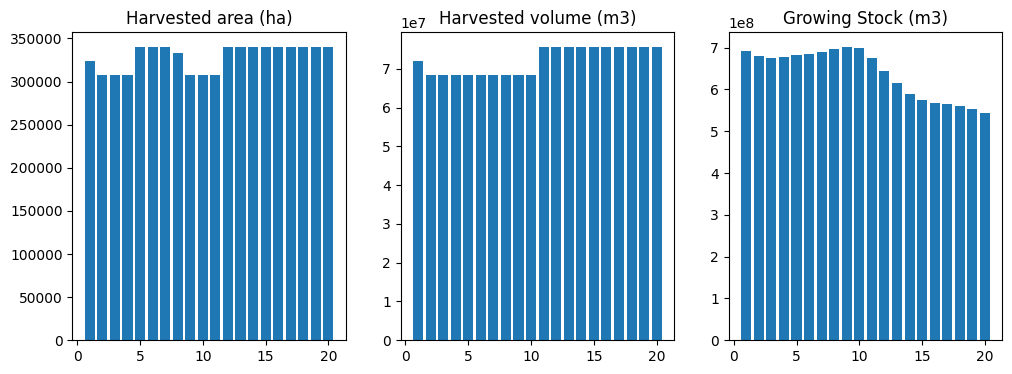

In [11]:
if problem.status() != ws3.opt.STATUS_OPTIMAL:
        print('Model not optimal.')
        df = None   
else:
    sch = fm.compile_schedule(problem)
    fm.apply_schedule(sch, 
        force_integral_area=False, 
        override_operability=False,
        fuzzy_age=False,
        recourse_enabled=False,
        verbose=False,
        compile_c_ycomps=True
    )
    df = compile_scenario(fm)
    print(df)
    fig, ax = plot_scenario(df)

Rebuild and solve the same problem, but with 2 cores.

In [12]:
workers = 2

In [13]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 2 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 224.74s


In [14]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  3s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         62    -9.3778657921e+09 Pr: 4412(6.28471e+08) 146s
        127    -8.1932871410e+09 Pr: 4203(4.61045e+08); Du: 0(9.41877e-08) 158s
        489    -7.4080343917e+09 Pr: 4081(7

Rebuild and solve the same problem, but with 4 cores.

In [15]:
workers = 4

In [16]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 4 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 180.17s


In [17]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  3s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         76    -1.0090968799e+10 Pr: 4435(5.65204e+08) 132s
        134    -8.3735976761e+09 Pr: 4198(2.35676e+08) 142s
        551    -7.3666232510e+09 Pr: 4085(7.74913e+07) 148s
   

Rebuild and solve the same problem, but with 8 cores.

In [18]:
workers = 8

In [19]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 8 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 199.71s


In [20]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  4s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         71    -9.1403711680e+09 Pr: 4398(7.6073e+08) 147s
        129    -8.1701817935e+09 Pr: 4203(2.90735e+08) 155s
       1144    -6.5908877337e+09 Pr: 3836(1.60856e+08) 161s
    

Rebuild and solve the same problem, but with 16 cores.

In [21]:
workers = 16

In [22]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 16 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 227.73s


In [23]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  3s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         66    -1.1251912865e+10 Pr: 4375(1.73568e+09) 151s
        121    -8.4309021230e+09 Pr: 4410(3.91691e+08) 179s
        448    -7.5477651357e+09 Pr: 4106(1.65751e+08) 185s
   

Rebuild and solve the same problem, but with 32 cores.

In [24]:
workers = 32

In [25]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 32 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 254.56s


In [26]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  3s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         68    -9.8287125279e+09 Pr: 4436(4.32668e+08) 154s
        128    -8.2487637044e+09 Pr: 4122(2.29633e+08) 173s
        574    -7.2733102617e+09 Pr: 4108(8.02629e+07) 178s
   

Rebuild and solve the same problem, but with 64 cores.

In [27]:
workers = 64

In [28]:
t0 = time.perf_counter()
problem = fm.add_problem(
    name="test",
    coeff_funcs=coeff_funcs, 
    cflw_e=cflw_e, 
    cgen_data=cgen_data,
    acodes=acodes,
    sense=ws3.opt.SENSE_MAXIMIZE, 
    mask=None,
    workers=workers,
    verbose=True
)
t1 = time.perf_counter()
print(f"Build time: {t1 - t0:.2f}s")

add_problem: build problem
generate trees using 64 workers
process trees
_bld_p_m1: build problem
_bld_p_m1: done building problem
add_problem: compile flow constraints
_cmp_cflw_m1: phase 1
_cmp_cflw_m1: phase 2
_cmp_cflw_m1: phase 3
add_problem: compile general constraints
Build time: 284.35s


In [29]:
problem.solve(verbose=True, threads=workers)


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7778 rows; 461956 cols; 10014103 nonzeros
Coefficient ranges:
  Matrix [1e-03, 1e+07]
  Cost   [3e+00, 2e+07]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+09]
Presolving model
4476 rows, 458658 cols, 9697481 nonzeros  4s
Dependent equations search running on 4398 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
4475 rows, 458658 cols, 9413474 nonzeros  5s
Presolve : Reductions: rows 4475(-3303); columns 458658(-3298); elements 9413474(-600629)
Solving the presolved LP
Using EKK parallel dual simplex solver - SIP with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 7s
         67    -9.4437714651e+09 Pr: 4442(2.68216e+09) 173s
        125    -8.2555413978e+09 Pr: 4145(2.33438e+08) 186s
        545    -7.3750742902e+09 Pr: 4206(7.90811e+07) 192s
   

So we can see from these results that throwing more cores at this problem improves performance, we do not get a benefit past 8 cores. As with many parallel processing problems, performance benefits of adding more parallel cores eventually gets overpowered by the fixed cost of worker process initialization (i.e., IPC cost from serialization of data that needs to be sent to and from worker threads at the start and end of work batches). The current parallel implementation in `ws3` requires a substantial amount of data to be sent back and forth, so this equilibrium maxes out relatively quickly. Hopefully in a future release we can find a way to reduce IPC cost, and maybe squeeze benefits from adding more cores if they are available.

Next, we run profiling on 4, 8, and 16 core model building runs to get some more insight into what exactly is dominating runtime for these three cases.

In [30]:
for workers in [1, 2, 4, 8, 16, 32, 64]:
    print("Building problem with", workers, "workers")
    pr = cProfile.Profile()
    pr.enable()
    problem = fm.add_problem(
        name="test",
        coeff_funcs=coeff_funcs, 
        cflw_e=cflw_e, 
        cgen_data=cgen_data,
        acodes=acodes,
        sense=ws3.opt.SENSE_MAXIMIZE, 
        mask=None,
        workers=workers,
        verbose=False
    )
    pr.disable()
    
    s = io.StringIO()
    pstats.Stats(pr, stream=s).sort_stats("cumtime").print_stats(30)
    print(s.getvalue())

Building problem with 1 workers
         687767462 function calls (685741537 primitive calls) in 407.821 seconds

   Ordered by: cumulative time
   List reduced from 277 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       81    5.150    0.064 1050.072   12.964 /usr/lib/python3.12/asyncio/base_events.py:1910(_run_once)
        1    0.016    0.016  268.823  268.823 /home/gep/projects/ws3/ws3/forest.py:968(_bld_p_m1)
2033458/7696   18.879    0.000  236.965    0.031 /home/gep/projects/ws3/ws3/forest.py:1103(_bld_tree_m1)
       80   31.158    0.389  104.831    1.310 /usr/lib/python3.12/selectors.py:451(select)
  2682351   11.983    0.000   74.048    0.000 /home/gep/projects/ws3/ws3/forest.py:1495(compile_product)
      375   34.520    0.092   72.136    0.192 {built-in method time.sleep}
      2/1    4.492    2.246   65.126   65.126 /home/gep/projects/ws3/ws3/forest.py:872(add_problem)
  2487718   28.985    0.000   53.620    0.000 /h

# Picking `max_workers` in `ws3`: quick guidance + deeper dive

This note summarizes what we learned from running the build-phase under `cProfile` at 1, 2, 4, 8, 16, 32, 64 workers. It has two parts:

- **Part A (quick start)**: practical advice for folks who just want a good `max_workers` value.
- **Part B (deep dive)**: how to read the `cProfile` output, what’s actually fast vs slow, and what to tweak if you’re hacking on the parallel code.

---

## Part A — Quick start (what number should I use?)

**TL;DR for this dataset/machine**  
Our wall-time results (build phase only):

| workers | build wall time (s) |
|---:|---:|
| 1 | 407.8 |
| 2 | 390.4 |
| 4 | 294.2 |
| 8 | 301.2 |
| **16** | **276.5** ← best here |
| 32 | 324.3 |
| 64 | 385.8 |

**Recommendation:**  
- Start with **`max_workers=16`** on similar problem sizes/hardware.  
- If you have fewer physical cores, try **half your cores** (e.g., 8 on a 16-core box).  
- If you have many more cores (72–150), don’t jump straight to huge worker counts—**diminishing returns** and **overhead** kick in quickly.

**When to reduce workers:**  
- If you see *more* time spent with many workers than with fewer ones, drop to the smallest `N` near the best time (here, 16).  
- If the model is small, **stick with serial** (`max_workers=1`)—parallel overhead can dominate.

**HiGHS threads:**  
If you build **and** solve in the same session, don’t give both the builder and HiGHS all cores. Example: **16 build workers + 8 solver threads** is often a good split.

---

## Part B — Deep dive (reading the profile, tuning, and hacking)

### 1) Interpreting the profiles

In good scaling regions (e.g., 4–16 workers above), the top cumulative-time frames are **productive compute**:

- `forest._bld_tree_m1` (DFS tree construction)
- `forest.compile_product`, `forest.apply_action`
- `common.paths` / `common.path`
- Your coefficient functions (e.g., `examples.util.cmp_c_*`)

As you **overshoot** the sweet spot (32–64 workers above), **overhead** climbs into the top slots:

- `selectors.select`, `connection.wait`, `poll` (multiprocessing pipes/queues)
- `Pickler.dump` / `_pickle.loads` (task/result serialization)
- `threading._wait_for_tstate_lock` / mass `acquire` calls (contention)
- `concurrent.futures.process` join/shutdown
- `time.sleep` backoffs in the executor
- `asyncio.base_events._run_once` (Jupyter event loop noise)

When overhead frames rival or exceed your compute frames in the **top 10 cumulative** list, you’ve passed the knee of the curve.

### 2) Choosing `max_workers` methodically

1. Run a small sweep: `1, 2, 4, 8, 16, 32` (and 64 only if you must).  
2. Plot wall time vs workers (or just eyeball the printed numbers).  
3. Pick the **smallest** worker count near the **lowest** wall time where compute still dominates the top of the profile.  
   - In our run: **16**.

A simple heuristic for first tries:
- **Small models**: 1 (serial).
- **Medium**: 4–8.
- **Large**: 8–16.
- **Very large**: try 16 first; 32 only if you see clear gains (rare on single machine unless tasks are very chunky and memory is ample).

### 3) Batch sizing

We batch work per process to amortize scheduling and pickling costs. A practical rule:

```text
batch_size ≈ len(tasks) // (2–4 * max_workers) + 1